In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import jit, value_and_grad

from scipy.optimize import minimize

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)
print("JAX version:", jax.__version__)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures
JAX version: 0.6.2


In [2]:
from cartpole import CartPole, remap_angle

STATE_NAMES = ["x", "x_dot", "theta", "theta_dot"]

DELTA_NAMES = [
    "Delta x",
    "Delta x_dot",
    "Delta theta",
    "Delta theta_dot",
]


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path


def mse_np(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)


def mse_per_dimension_np(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2, axis=0)

In [3]:
dataset_path = DATA_DIR / "task1_3_linear_model_dataset_500.npz"

data = np.load(dataset_path)

X_initial = data["X_initial"]
Delta_X = data["Delta_X"]

print("Loaded dataset:", dataset_path)
print("X_initial shape:", X_initial.shape)
print("Delta_X shape:", Delta_X.shape)

Loaded dataset: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_3_linear_model_dataset_500.npz
X_initial shape: (500, 4)
Delta_X shape: (500, 4)


In [4]:
N = X_initial.shape[0]

rng = np.random.default_rng(123)
indices = rng.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train_np = X_initial[train_idx]
Y_train_np = Delta_X[train_idx]

X_val_np = X_initial[val_idx]
Y_val_np = Delta_X[val_idx]

X_test_np = X_initial[test_idx]
Y_test_np = Delta_X[test_idx]

print("X_train_np shape:", X_train_np.shape)
print("Y_train_np shape:", Y_train_np.shape)

print("X_val_np shape:", X_val_np.shape)
print("Y_val_np shape:", Y_val_np.shape)

print("X_test_np shape:", X_test_np.shape)
print("Y_test_np shape:", Y_test_np.shape)

X_train_np shape: (300, 4)
Y_train_np shape: (300, 4)
X_val_np shape: (100, 4)
Y_val_np shape: (100, 4)
X_test_np shape: (100, 4)
Y_test_np shape: (100, 4)


In [5]:
M = 80

rng = np.random.default_rng(456)
centre_indices = rng.choice(X_train_np.shape[0], size=M, replace=False)
centres_np = X_train_np[centre_indices]

print("M:", M)
print("centres_np shape:", centres_np.shape)

M: 80
centres_np shape: (80, 4)


In [6]:
X_train = jnp.array(X_train_np)
Y_train = jnp.array(Y_train_np)

X_val = jnp.array(X_val_np)
Y_val = jnp.array(Y_val_np)

X_test = jnp.array(X_test_np)
Y_test = jnp.array(Y_test_np)

centres = jnp.array(centres_np)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("centres shape:", centres.shape)

X_train shape: (300, 4)
Y_train shape: (300, 4)
centres shape: (80, 4)


In [7]:
def gaussian_kernel_matrix_jax(X_a, X_b, length_scales):
    """
    Gaussian kernel matrix with periodic angle component.

    X_a shape: (N, 4)
    X_b shape: (M, 4)
    length_scales shape: (4,)

    returns:
        K shape: (N, M)
    """
    diff = X_a[:, None, :] - X_b[None, :, :]

    squared_terms = diff ** 2

    # Replace raw theta squared difference with periodic distance.
    theta_diff = diff[:, :, 2]
    periodic_theta_term = jnp.sin(theta_diff / 2.0) ** 2

    squared_terms = squared_terms.at[:, :, 2].set(periodic_theta_term)

    scaled_squared = squared_terms / (2.0 * length_scales[None, None, :] ** 2)

    K = jnp.exp(-jnp.sum(scaled_squared, axis=2))

    return K

In [8]:
def fit_kernel_model_jax(X_train, Y_train, centres, length_scales, reg_strength):
    """
    Fit sparse Gaussian kernel model in JAX.

    Model:
        Y_hat = K_NM alpha

    Regularised sparse kernel solution:
        alpha = solve(K_MN K_NM + lambda K_MM + jitter I, K_MN Y)

    returns:
        alpha shape: (M, 4)
    """
    K_NM = gaussian_kernel_matrix_jax(
        X_train,
        centres,
        length_scales,
    )

    K_MN = K_NM.T

    K_MM = gaussian_kernel_matrix_jax(
        centres,
        centres,
        length_scales,
    )

    M = centres.shape[0]

    jitter = 1e-8

    A = K_MN @ K_NM + reg_strength * K_MM + jitter * jnp.eye(M)
    rhs = K_MN @ Y_train

    alpha = jnp.linalg.solve(A, rhs)

    return alpha

In [9]:
def predict_kernel_model_jax(X_query, centres, length_scales, alpha):
    K_query = gaussian_kernel_matrix_jax(
        X_query,
        centres,
        length_scales,
    )

    Y_pred = K_query @ alpha

    return Y_pred

In [10]:
def validation_mse_from_log_hyperparams(log_hyperparams):
    """
    Takes log hyperparameters:
        log_hyperparams[:4] = log length scales
        log_hyperparams[4] = log lambda

    Returns:
        validation MSE after fitting alpha on training data.
    """
    length_scales = jnp.exp(log_hyperparams[:4])
    reg_strength = jnp.exp(log_hyperparams[4])

    alpha = fit_kernel_model_jax(
        X_train,
        Y_train,
        centres,
        length_scales,
        reg_strength,
    )

    Y_pred_val = predict_kernel_model_jax(
        X_val,
        centres,
        length_scales,
        alpha,
    )

    errors = Y_pred_val - Y_val
    val_mse = jnp.mean(errors ** 2)

    return val_mse

In [11]:
initial_length_scales_np = np.std(X_train_np, axis=0)
initial_length_scales_np = np.maximum(initial_length_scales_np, 1e-6)

initial_lambda_np = 1e-3

initial_log_hyperparams_np = np.log(
    np.concatenate([
        initial_length_scales_np,
        np.array([initial_lambda_np]),
    ])
)

print("Initial length scales:")
for name, value in zip(STATE_NAMES, initial_length_scales_np):
    print(f"{name}: {value}")

print("Initial lambda:", initial_lambda_np)
print("initial_log_hyperparams_np:", initial_log_hyperparams_np)

Initial length scales:
x: 2.83338633683756
x_dot: 5.978452329146146
theta: 1.8177838699360096
theta_dot: 8.336796171230914
Initial lambda: 0.001
initial_log_hyperparams_np: [ 1.04147258  1.78816173  0.59761811  2.12067899 -6.90775528]


In [12]:
objective_value_and_grad = value_and_grad(validation_mse_from_log_hyperparams)

initial_log_hyperparams = jnp.array(initial_log_hyperparams_np)

initial_value, initial_grad = objective_value_and_grad(initial_log_hyperparams)

print("Initial validation MSE:", initial_value)
print("Initial gradient shape:", initial_grad.shape)
print("Initial gradient:")
print(initial_grad)

Initial validation MSE: 0.7974233754855443
Initial gradient shape: (5,)
Initial gradient:
[-0.09605273 -0.22164932  0.23043374 -0.36276332 -0.00107591]


In [13]:
objective_value_and_grad_jit = jit(objective_value_and_grad)

# First call triggers compilation.
initial_value_jit, initial_grad_jit = objective_value_and_grad_jit(initial_log_hyperparams)

print("Initial validation MSE after JIT:", initial_value_jit)
print("Initial gradient after JIT:", initial_grad_jit)

Initial validation MSE after JIT: 0.7974233754869708
Initial gradient after JIT: [-0.09605273 -0.22164932  0.23043374 -0.36276332 -0.00107591]


In [14]:
objective_history = []


def scipy_objective(log_hyperparams_np):
    log_hyperparams_jax = jnp.array(log_hyperparams_np)

    value, gradient = objective_value_and_grad_jit(log_hyperparams_jax)

    value_np = float(value)
    gradient_np = np.array(gradient, dtype=float)

    objective_history.append(value_np)

    return value_np, gradient_np

In [15]:
sigma_lower = 0.05
sigma_upper = 50.0

lambda_lower = 1e-8
lambda_upper = 1e-1

bounds = [
    (np.log(sigma_lower), np.log(sigma_upper)),  # sigma_x
    (np.log(sigma_lower), np.log(sigma_upper)),  # sigma_x_dot
    (np.log(sigma_lower), np.log(sigma_upper)),  # sigma_theta
    (np.log(sigma_lower), np.log(sigma_upper)),  # sigma_theta_dot
    (np.log(lambda_lower), np.log(lambda_upper)),  # lambda
]

print("Bounds in original scale:")
for name, lower_upper in zip(
    STATE_NAMES + ["lambda"],
    [(sigma_lower, sigma_upper)] * 4 + [(lambda_lower, lambda_upper)],
):
    print(name, lower_upper)

Bounds in original scale:
x (0.05, 50.0)
x_dot (0.05, 50.0)
theta (0.05, 50.0)
theta_dot (0.05, 50.0)
lambda (1e-08, 0.1)


In [16]:
result = minimize(
    fun=scipy_objective,
    x0=initial_log_hyperparams_np,
    method="L-BFGS-B",
    jac=True,
    bounds=bounds,
    options={
        "maxiter": 60,
        "ftol": 1e-10,
        "gtol": 1e-6,
        "disp": True,
    },
)

print("Optimisation success:", result.success)
print("Message:", result.message)
print("Number of iterations:", result.nit)
print("Number of function evaluations:", result.nfev)

print("\nInitial validation MSE:", float(initial_value))
print("Optimised validation MSE:", result.fun)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.97423D-01    |proj g|=  3.62763D-01

At iterate    1    f=  6.03214D-01    |proj g|=  4.04862D-01

At iterate    2    f=  1.37340D-01    |proj g|=  1.31163D-01

At iterate    3    f=  1.05849D-01    |proj g|=  2.97210D-02

At iterate    4    f=  1.02969D-01    |proj g|=  2.48575D-02

At iterate    5    f=  9.49427D-02    |proj g|=  1.58850D-02

At iterate    6    f=  8.52162D-02    |proj g|=  1.40080D-02
  ys=-2.552E-04  -gs= 8.342E-03 BFGS update SKIPPED

At iterate    7    f=  8.09651D-02    |proj g|=  6.78582D-03

At iterate    8    f=  7.97789D-02    |proj g|=  6.35192D-03

At iterate    9    f=  7.90982D-02    |proj g|=  3.16419D-03

At iterate   10    f=  7.84228D-02    |proj g|=  5.98163D-03

At iterate   11    f=  7.82303D-02    |proj g|=  3.68017D-03

At iterate   12    f=  7.79444D-02  

In [17]:
optimised_log_hyperparams_np = result.x

optimised_hyperparams_np = np.exp(optimised_log_hyperparams_np)

optimised_length_scales_np = optimised_hyperparams_np[:4]
optimised_lambda_np = optimised_hyperparams_np[4]

print("Initial length scales:")
for name, value in zip(STATE_NAMES, initial_length_scales_np):
    print(f"  {name}: {value}")

print("Initial lambda:", initial_lambda_np)

print("\nOptimised length scales:")
for name, value in zip(STATE_NAMES, optimised_length_scales_np):
    print(f"  {name}: {value}")

print("Optimised lambda:", optimised_lambda_np)

Initial length scales:
  x: 2.83338633683756
  x_dot: 5.978452329146146
  theta: 1.8177838699360096
  theta_dot: 8.336796171230914
Initial lambda: 0.001

Optimised length scales:
  x: 49.99999999999999
  x_dot: 49.99999999999999
  theta: 0.3889662962765201
  theta_dot: 7.380819940058085
Optimised lambda: 2.4581608464579644e-07


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_2_validation_mse_optimisation_history.png


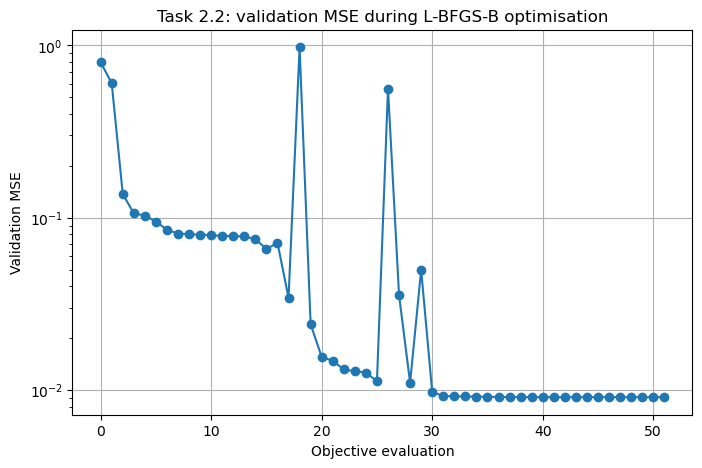

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(objective_history, marker="o")

ax.set_xlabel("Objective evaluation")
ax.set_ylabel("Validation MSE")
ax.set_title("Task 2.2: validation MSE during L-BFGS-B optimisation")
ax.set_yscale("log")
ax.grid(True)

save_figure(fig, "sf3_task2_2_validation_mse_optimisation_history.png")
plt.show()

In [19]:
def fit_and_evaluate_np(length_scales_np, reg_strength_np):
    length_scales_jax = jnp.array(length_scales_np)
    reg_strength_jax = jnp.array(reg_strength_np)

    alpha_jax = fit_kernel_model_jax(
        X_train,
        Y_train,
        centres,
        length_scales_jax,
        reg_strength_jax,
    )

    Y_pred_train_jax = predict_kernel_model_jax(
        X_train,
        centres,
        length_scales_jax,
        alpha_jax,
    )

    Y_pred_val_jax = predict_kernel_model_jax(
        X_val,
        centres,
        length_scales_jax,
        alpha_jax,
    )

    Y_pred_test_jax = predict_kernel_model_jax(
        X_test,
        centres,
        length_scales_jax,
        alpha_jax,
    )

    alpha_np = np.array(alpha_jax)
    Y_pred_train_np = np.array(Y_pred_train_jax)
    Y_pred_val_np = np.array(Y_pred_val_jax)
    Y_pred_test_np = np.array(Y_pred_test_jax)

    metrics = {
        "train_mse": mse_np(Y_train_np, Y_pred_train_np),
        "val_mse": mse_np(Y_val_np, Y_pred_val_np),
        "test_mse": mse_np(Y_test_np, Y_pred_test_np),
        "train_mse_dim": mse_per_dimension_np(Y_train_np, Y_pred_train_np),
        "val_mse_dim": mse_per_dimension_np(Y_val_np, Y_pred_val_np),
        "test_mse_dim": mse_per_dimension_np(Y_test_np, Y_pred_test_np),
    }

    return alpha_np, Y_pred_train_np, Y_pred_val_np, Y_pred_test_np, metrics

In [20]:
alpha_initial_np, Y_pred_train_initial, Y_pred_val_initial, Y_pred_test_initial, metrics_initial = fit_and_evaluate_np(
    initial_length_scales_np,
    initial_lambda_np,
)

alpha_optimised_np, Y_pred_train_optimised, Y_pred_val_optimised, Y_pred_test_optimised, metrics_optimised = fit_and_evaluate_np(
    optimised_length_scales_np,
    optimised_lambda_np,
)

print("Initial model MSE:")
print(metrics_initial)

print("\nOptimised model MSE:")
print(metrics_optimised)

Initial model MSE:
{'train_mse': 0.2737293509230646, 'val_mse': 0.7974233754869098, 'test_mse': 0.6814465641344227, 'train_mse_dim': array([0.00171267, 0.12619224, 0.00477688, 0.96223561]), 'val_mse_dim': array([0.00449583, 0.21702709, 0.01199393, 2.95617665]), 'test_mse_dim': array([0.00308403, 0.25062968, 0.01154052, 2.46053203])}

Optimised model MSE:
{'train_mse': 0.0034282638937319075, 'val_mse': 0.00909037213134734, 'test_mse': 0.006623519730453753, 'train_mse_dim': array([0.0008748 , 0.00161132, 0.00010288, 0.01112406]), 'val_mse_dim': array([0.00357264, 0.00467107, 0.00032092, 0.02779686]), 'test_mse_dim': array([0.00216032, 0.00334053, 0.00032109, 0.02067214])}


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_2_mse_before_after_optimisation.png


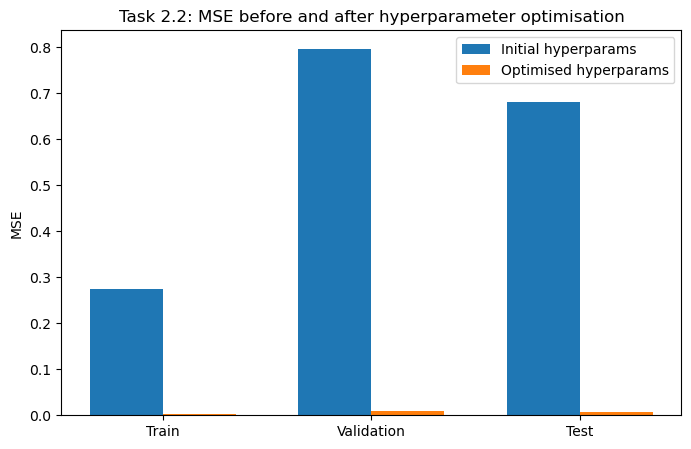

In [21]:
split_names = ["Train", "Validation", "Test"]

initial_values = [
    metrics_initial["train_mse"],
    metrics_initial["val_mse"],
    metrics_initial["test_mse"],
]

optimised_values = [
    metrics_optimised["train_mse"],
    metrics_optimised["val_mse"],
    metrics_optimised["test_mse"],
]

positions = np.arange(len(split_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(positions - width / 2, initial_values, width, label="Initial hyperparams")
ax.bar(positions + width / 2, optimised_values, width, label="Optimised hyperparams")

ax.set_xticks(positions)
ax.set_xticklabels(split_names)
ax.set_ylabel("MSE")
ax.set_title("Task 2.2: MSE before and after hyperparameter optimisation")
ax.legend()

save_figure(fig, "sf3_task2_2_mse_before_after_optimisation.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_2_prediction_vs_truth_before_after.png


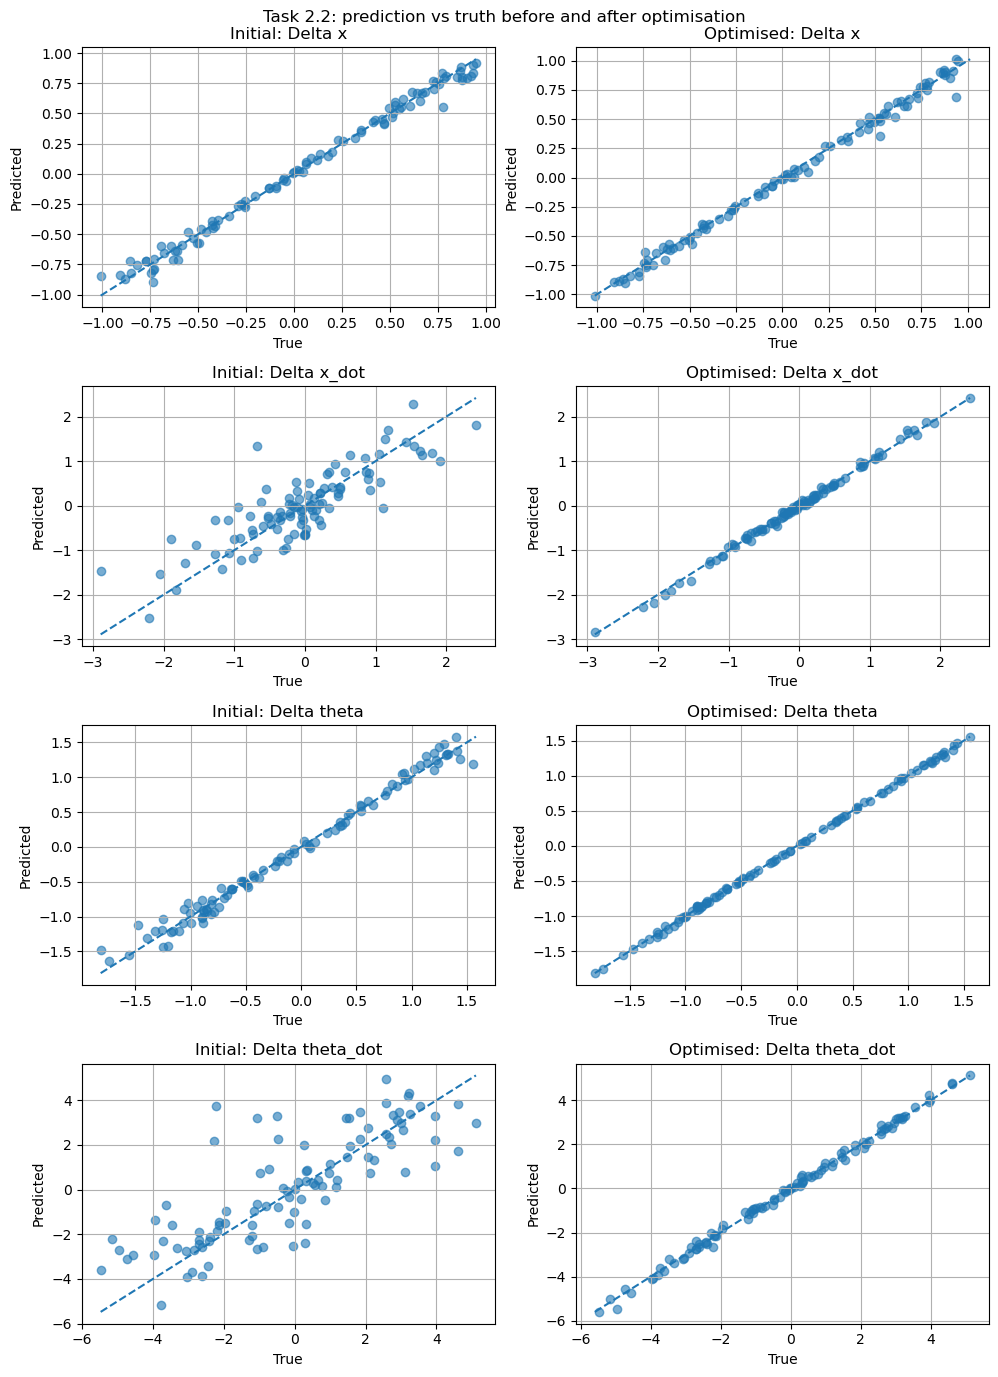

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for dim in range(4):
    # Initial
    ax = axes[dim, 0]

    y_true = Y_test_np[:, dim]
    y_pred = Y_pred_test_initial[:, dim]

    ax.scatter(y_true, y_pred, alpha=0.6)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    ax.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    ax.set_title(f"Initial: {DELTA_NAMES[dim]}")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)

    # Optimised
    ax = axes[dim, 1]

    y_pred = Y_pred_test_optimised[:, dim]

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    ax.set_title(f"Optimised: {DELTA_NAMES[dim]}")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)

fig.suptitle("Task 2.2: prediction vs truth before and after optimisation")
fig.tight_layout()

save_figure(fig, "sf3_task2_2_prediction_vs_truth_before_after.png")
plt.show()

In [23]:
model_path = DATA_DIR / "task2_2_optimised_kernel_model.npz"

np.savez(
    model_path,
    centres=centres_np,
    alpha=alpha_optimised_np,
    length_scales=optimised_length_scales_np,
    reg_strength=optimised_lambda_np,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    M=M,
)

print("Saved optimised kernel model to:", model_path)

Saved optimised kernel model to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task2_2_optimised_kernel_model.npz


In [24]:
def one_step_true_zero_force(initial_state):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()
    delta_x = x_next - x0

    return x0, x_next, delta_x


def rollout_true_zero_force(initial_state, num_steps):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = system.getState()

    for step in range(num_steps):
        system.performAction(0.0)
        trajectory[step + 1] = system.getState()

    return trajectory


def predict_kernel_model_np(X_query, centres_np, length_scales_np, alpha_np):
    X_query_jax = jnp.array(X_query)
    centres_jax = jnp.array(centres_np)
    length_scales_jax = jnp.array(length_scales_np)
    alpha_jax = jnp.array(alpha_np)

    Y_pred_jax = predict_kernel_model_jax(
        X_query_jax,
        centres_jax,
        length_scales_jax,
        alpha_jax,
    )

    return np.array(Y_pred_jax)


def rollout_kernel_model_np(
    initial_state,
    num_steps,
    centres_np,
    length_scales_np,
    alpha_np,
    remap_theta=True,
):
    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = np.asarray(initial_state, dtype=float)

    if remap_theta:
        trajectory[0, 2] = remap_angle(trajectory[0, 2])

    for step in range(num_steps):
        current_state = trajectory[step]

        delta_pred = predict_kernel_model_np(
            current_state[None, :],
            centres_np,
            length_scales_np,
            alpha_np,
        )[0]

        next_state = current_state + delta_pred

        if remap_theta:
            next_state[2] = remap_angle(next_state[2])

        trajectory[step + 1] = next_state

    return trajectory


def remap_trajectory_angle_np(trajectory):
    trajectory_copy = trajectory.copy()
    trajectory_copy[:, 2] = np.array([remap_angle(theta) for theta in trajectory_copy[:, 2]])
    return trajectory_copy

In [25]:
initial_state_rollout = np.array([0.0, 0.0, np.pi, 8.0])
num_steps_rollout = 80

true_traj = rollout_true_zero_force(initial_state_rollout, num_steps_rollout)

kernel_traj_initial = rollout_kernel_model_np(
    initial_state_rollout,
    num_steps_rollout,
    centres_np,
    initial_length_scales_np,
    alpha_initial_np,
    remap_theta=True,
)

kernel_traj_optimised = rollout_kernel_model_np(
    initial_state_rollout,
    num_steps_rollout,
    centres_np,
    optimised_length_scales_np,
    alpha_optimised_np,
    remap_theta=True,
)

true_plot = remap_trajectory_angle_np(true_traj)
initial_plot = kernel_traj_initial.copy()
optimised_plot = kernel_traj_optimised.copy()

error_initial = np.linalg.norm(initial_plot - true_plot, axis=1)
error_optimised = np.linalg.norm(optimised_plot - true_plot, axis=1)

print("Initial rollout error after 10:", error_initial[10])
print("Optimised rollout error after 10:", error_optimised[10])

print("Initial rollout error after 20:", error_initial[20])
print("Optimised rollout error after 20:", error_optimised[20])

print("Initial final rollout error:", error_initial[-1])
print("Optimised final rollout error:", error_optimised[-1])

Initial rollout error after 10: 1.0836896614090683
Optimised rollout error after 10: 0.22503706963657794
Initial rollout error after 20: 5.115616981052035
Optimised rollout error after 20: 0.31003718957635157
Initial final rollout error: 25.51477241990867
Optimised final rollout error: 1.71595522886606


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_2_rollout_error_before_after.png


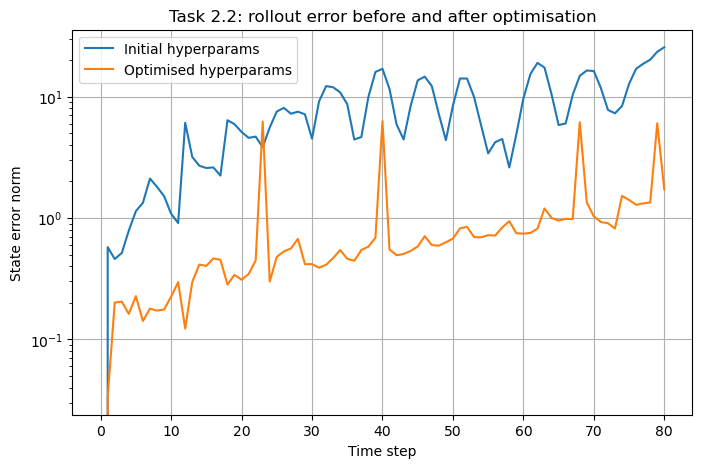

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

time = np.arange(num_steps_rollout + 1)

ax.plot(time, error_initial, label="Initial hyperparams")
ax.plot(time, error_optimised, label="Optimised hyperparams")

ax.set_xlabel("Time step")
ax.set_ylabel("State error norm")
ax.set_title("Task 2.2: rollout error before and after optimisation")
ax.set_yscale("log")
ax.grid(True)
ax.legend()

save_figure(fig, "sf3_task2_2_rollout_error_before_after.png")
plt.show()